# Evaluation of the models

In [5]:
from mlp import *
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd
import numpy as np
import tensorflow as tf
from tqdm import tqdm

tf.get_logger().setLevel('ERROR')

from mlp import LoadLabels, VerifyImagesExist, CreateTfDataset
from sklearn.model_selection import train_test_split

# 1. Reconstruct the exact same test DataFrame split (using default seed 42)
labels_df = LoadLabels()
labels_df, _ = VerifyImagesExist(labels_df)

train_df, temp_df = train_test_split(labels_df, test_size=0.3, random_state=42)
val_df, test_df = train_test_split(temp_df, test_size=0.5, random_state=42)

# 2. Reconstruct the global test_ds pipeline (used for models v2, v3, v4)
test_ds = CreateTfDataset(
    test_df, 
    batch_size=64, 
    image_size=(200, 200), 
    augment=False, 
    shuffle=False, 
    seed=42
)

print(f"✅ Success: 'test_df' ({len(test_df)} rows) and 'test_ds' are now live in memory!")

✅ Success: 'test_df' (3556 rows) and 'test_ds' are now live in memory!


## Model selection
- v1: base
- v2: early stopping + ethnicity based resampling
- v3: more complex prediction heads
- v4: 2 phase training

In [6]:
########## PARAMETERS ##########
version = 4
showSummary : bool = False
############################

model, history, metrics = LoadModelAndMetrics(base_path=f"models/gpu_v{version}")

if showSummary:
    model.summary()


## Plots

In [ ]:
import os
import numpy as np
import tensorflow as tf
from tqdm import tqdm

if not os.path.exists('preds'):
    os.makedirs('preds')

for v in [1, 2, 3, 4]:
    print(f"\n>>> PROCESSING: v{v}")
    
    # 1. Modell betöltése
    if v == 1:
        model = tf.keras.models.load_model("models/gpu_v1.keras")
        current_ds = CreateTfDataset(test_df, image_size=(128, 128), batch_size=64, augment=False, shuffle=False)
    else:
        model, _, _ = LoadModelAndMetrics(base_path=f"models/gpu_v{v}")
        current_ds = test_ds

    # 2. Manuális inferencia (Ezzel kikerüljük a 'predict' deadlock-ot)
    print(f" -> Manual batch processing...")
    
    batch_preds = []
    # Batch-enként dolgozzuk fel az adatot
    for batch in tqdm(current_ds, desc=f"v{v} batches"):
        # batch[0] a képek, batch[1] a címkék (amit figyelmen kívül hagyunk)
        p = model.predict(batch[0], verbose=0)
        batch_preds.append(p)
    
    # 3. Összefűzés (Concatenate)
    # A dictionary minden kulcsát (pl. 'gender', 'age') összefűzzük
    final_preds = {}
    for key in batch_preds[0].keys():
        final_preds[key] = np.concatenate([b[key] for b in batch_preds], axis=0)
    
    # 4. Mentés
    np.save(f'preds/preds_v{v}.npy', final_preds)
    print(f" -> Model v{v} saved.")

print("\n--- READY! ---")


>>> FELDOLGOZÁS: v1
 -> Manuális batch-feldolgozás indítása...


v1 batch-ek: 100%|██████████| 56/56 [03:08<00:00,  3.36s/it]


 -> Modell v1 mentve.

>>> FELDOLGOZÁS: v2
 -> Manuális batch-feldolgozás indítása...


v2 batch-ek: 100%|██████████| 56/56 [05:35<00:00,  6.00s/it]


 -> Modell v2 mentve.

>>> FELDOLGOZÁS: v3
 -> Manuális batch-feldolgozás indítása...


v3 batch-ek: 100%|██████████| 56/56 [06:01<00:00,  6.46s/it]


 -> Modell v3 mentve.

>>> FELDOLGOZÁS: v4
 -> Manuális batch-feldolgozás indítása...


v4 batch-ek: 100%|██████████| 56/56 [06:46<00:00,  7.26s/it]

 -> Modell v4 mentve.

--- MINDEN KÉSZ! ---


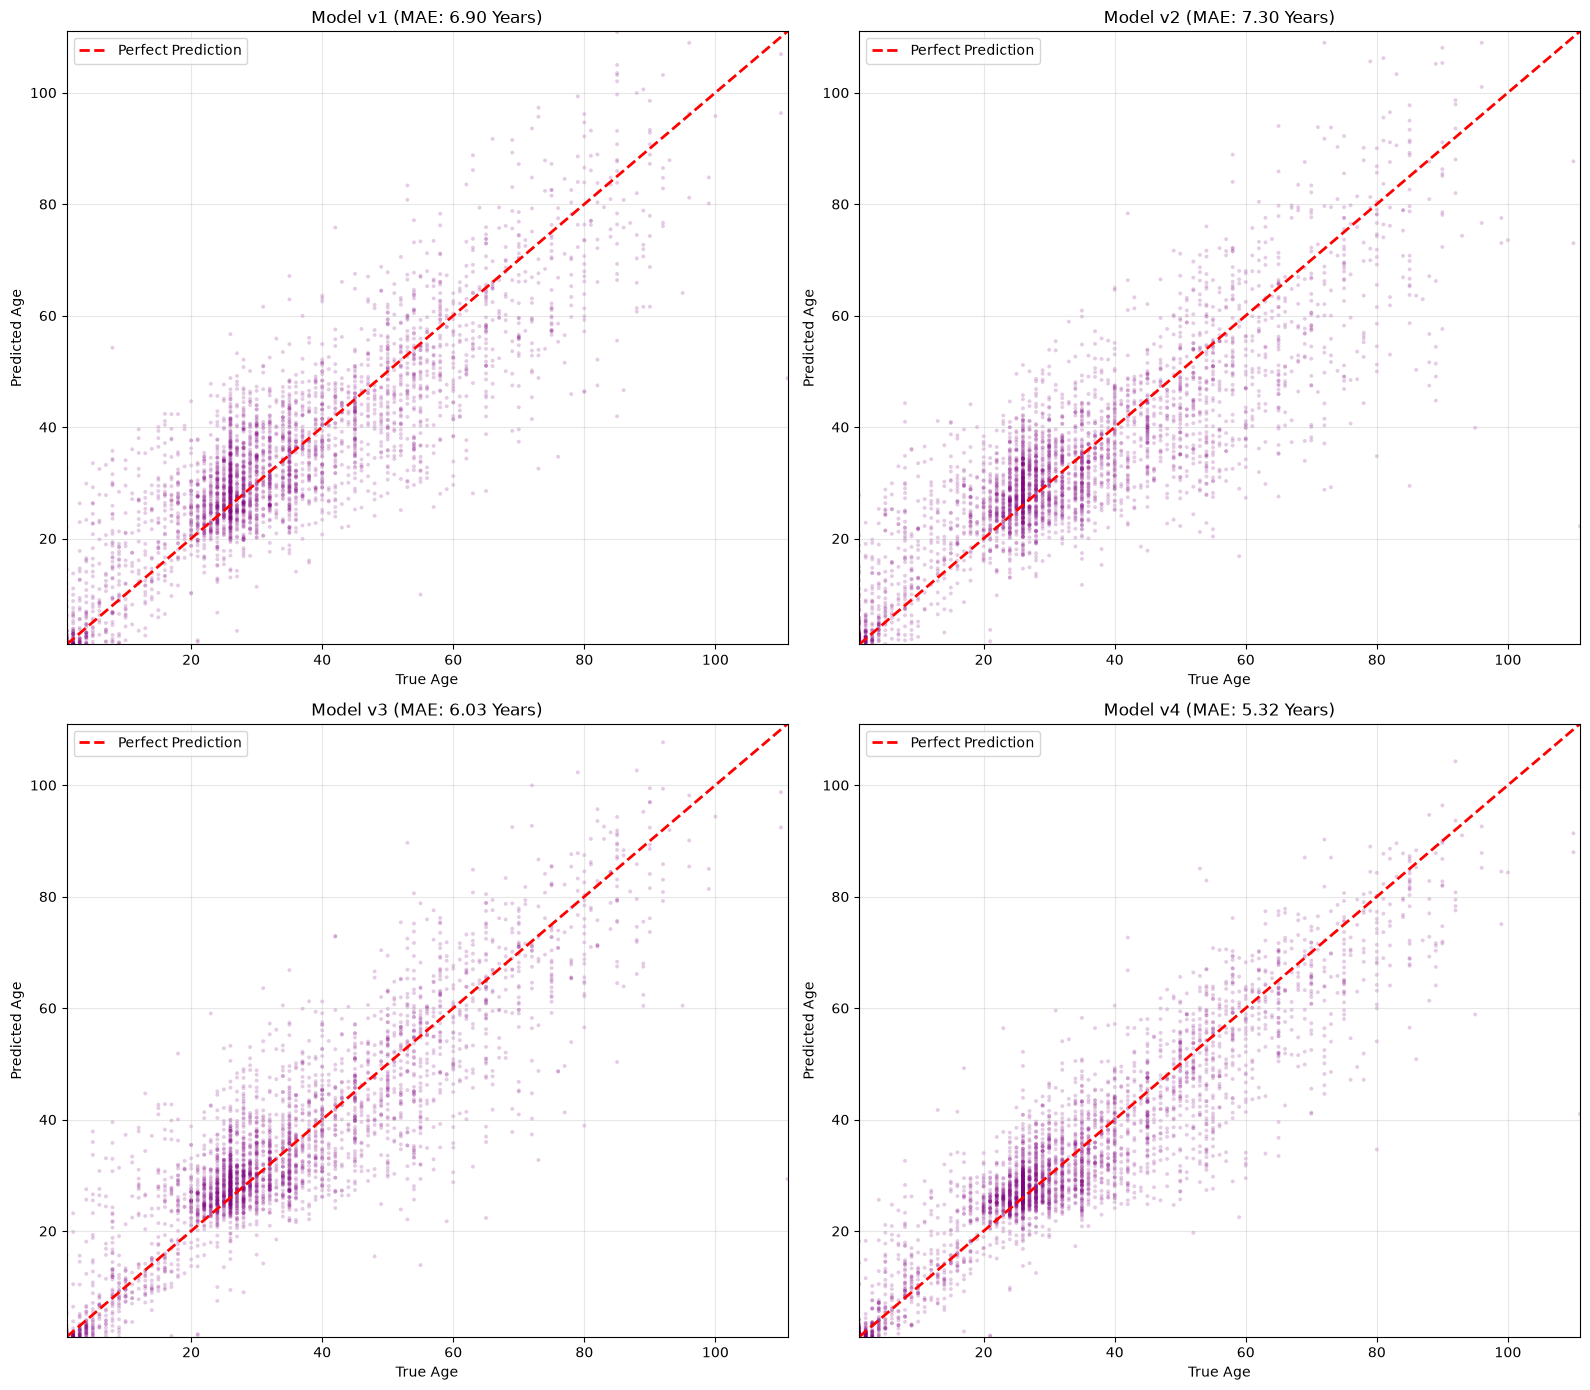

In [7]:
import numpy as np
import matplotlib.pyplot as plt
import os

fig, axes = plt.subplots(2, 2, figsize=(16, 14))
axes = axes.flatten()

# Get global min/max bounds across the dataset to keep axes consistent
true_ages = test_df['age'].values
min_age, max_age = int(true_ages.min()), int(true_ages.max())

for i, v in enumerate([1, 2, 3, 4]):
    ax = axes[i]
    file_path = f'preds/preds_v{v}.npy'
    
    if os.path.exists(file_path):
        preds = np.load(file_path, allow_pickle=True).item()
        pred_ages = preds["age"].flatten()
        
        # Calculate individual model MAE for the title
        mae = np.mean(np.abs(pred_ages - true_ages))
        
        # Plot the continuous sample cloud
        ax.scatter(true_ages, pred_ages, alpha=0.2, color='purple', edgecolors='none', s=8)
        
        # 45-degree Identity Line
        ax.plot([min_age, max_age], [min_age, max_age], color='red', linestyle='--', linewidth=2, label='Perfect Prediction')
        
        ax.set_title(f'Model v{v} (MAE: {mae:.2f} Years)')
        ax.set_xlabel('True Age')
        ax.set_ylabel('Predicted Age')
        ax.set_xlim(min_age, max_age)
        ax.set_ylim(min_age, max_age)
        ax.grid(True, alpha=0.3)
        ax.legend(loc='upper left')
    else:
        ax.text(0.5, 0.5, f"v{v} File Missing", ha='center', va='center', fontsize=12)

plt.tight_layout()
plt.show()

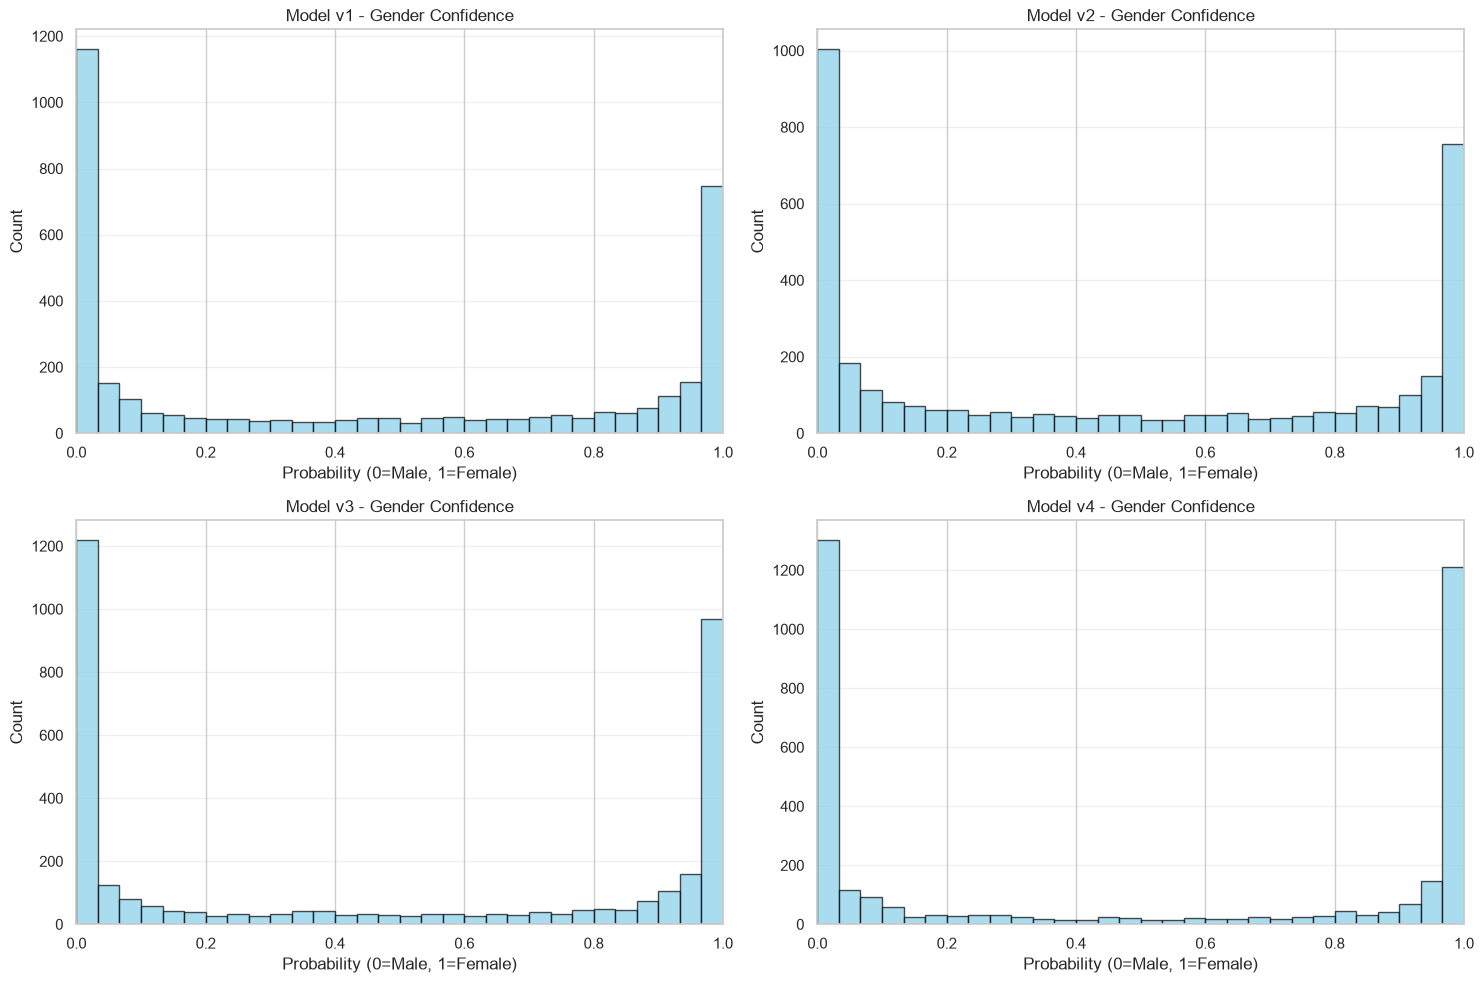

In [35]:


fig, axes = plt.subplots(2, 2, figsize=(15, 10))
axes = axes.flatten()

for i, v in enumerate([1, 2, 3, 4]):
    ax = axes[i]
    file_path = f'preds/preds_v{v}.npy'
    
    if os.path.exists(file_path):
        # Betöltjük a nyers valószínűségeket
        preds = np.load(file_path, allow_pickle=True).item()
        probs = preds["gender"].flatten()
        
        # Plot: Ez az, amit "U-alakúnak" hívtunk
        ax.hist(probs, bins=30, color='skyblue', edgecolor='black', alpha=0.7)
        
        ax.set_title(f'Model v{v} - Gender Confidence')
        ax.set_xlabel('Probability (0=Male, 1=Female)')
        ax.set_ylabel('Count')
        ax.set_xlim(0, 1)
        ax.grid(axis='y', alpha=0.3)
    else:
        ax.text(0.5, 0.5, "File missing", ha='center', va='center')

plt.tight_layout()
plt.show()

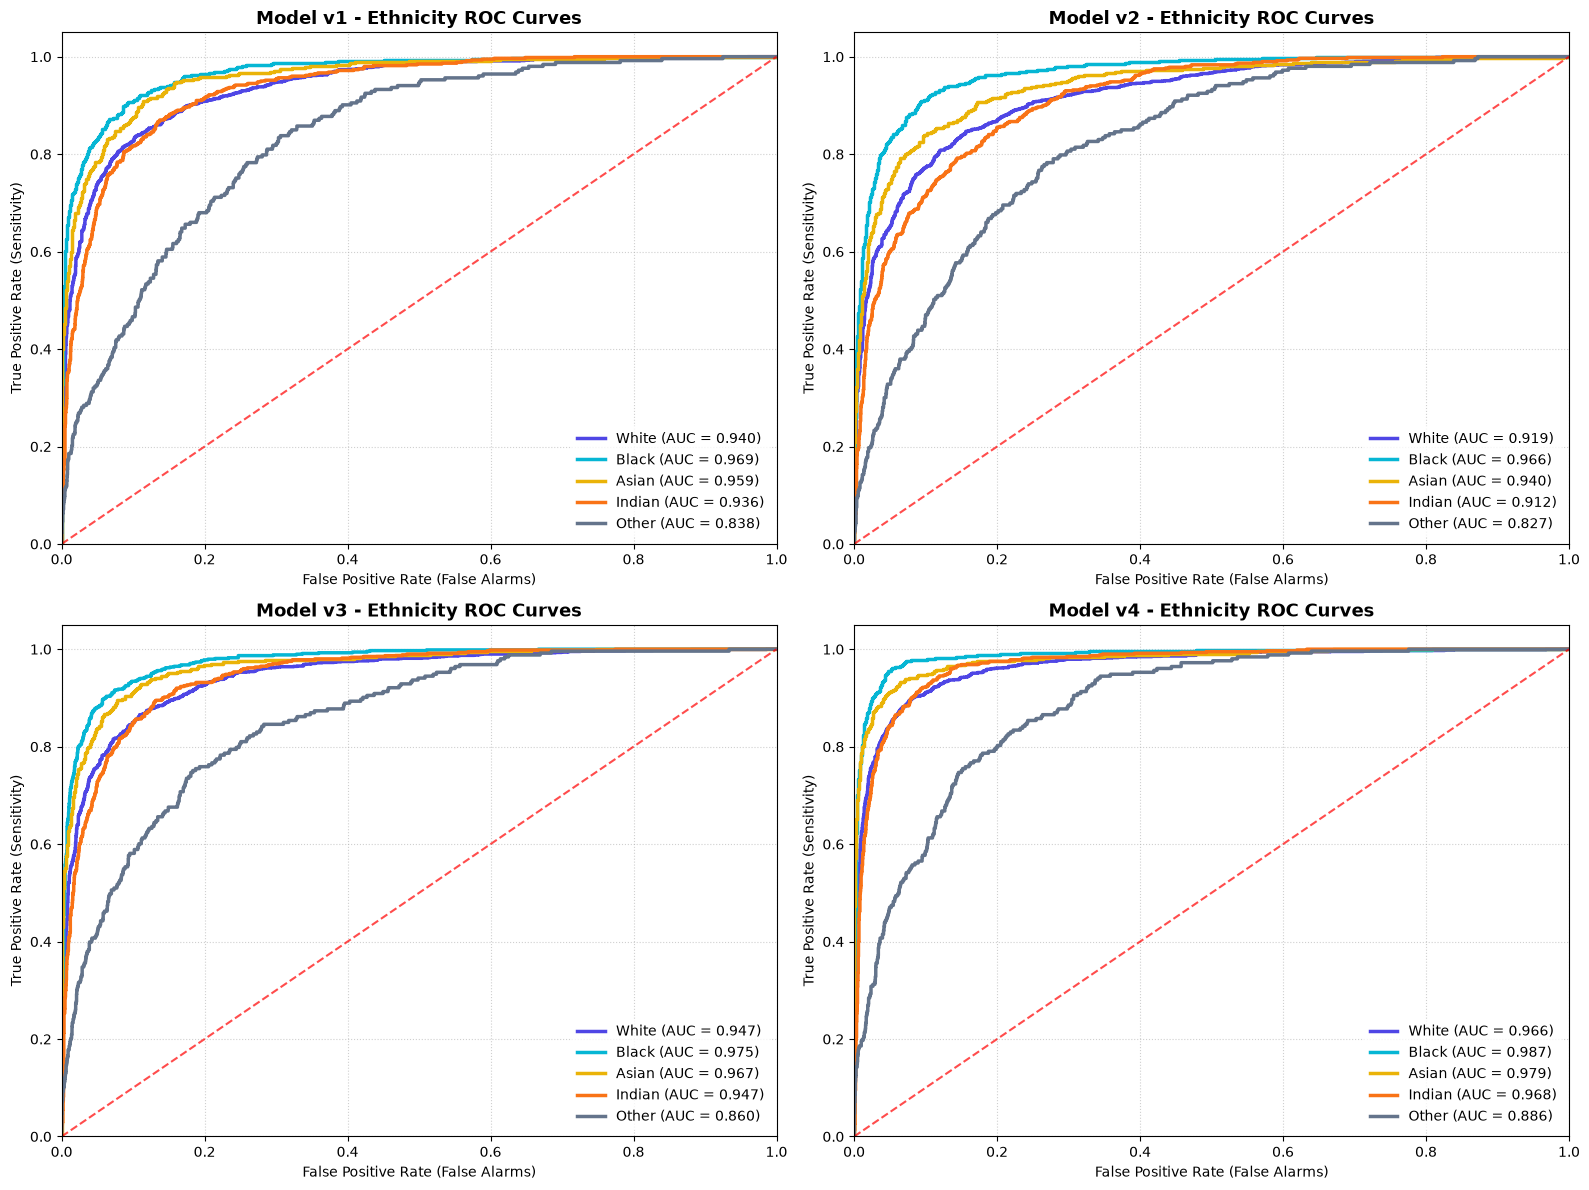

In [8]:

from sklearn.metrics import roc_curve, auc
from sklearn.preprocessing import label_binarize

labels = ['White', 'Black', 'Asian', 'Indian', 'Other']
n_classes = len(labels)

# Binarize true labels for multi-class ROC calculation (N, 5)
# Using your live test_df from memory
y_true_binarized = label_binarize(test_df['race'].values, classes=[0, 1, 2, 3, 4])

fig, axes = plt.subplots(2, 2, figsize=(16, 12))
axes = axes.flatten()

# Custom crisp color scheme for the lines
colors = ['#4f46e5', '#06b6d4', '#eab308', '#f97316', '#64748b']

for i, v in enumerate([1, 2, 3, 4]):
    ax = axes[i]
    file_path = f'preds/preds_v{v}.npy'
    
    if os.path.exists(file_path):
        preds = np.load(file_path, allow_pickle=True).item()
        ethnicity_probs = preds["ethnicity"]  # Shape: (N, 5) probability matrix
        
        # Calculate and plot ROC curve + AUC area for each specific class
        for class_idx in range(n_classes):
            fpr, tpr, _ = roc_curve(y_true_binarized[:, class_idx], ethnicity_probs[:, class_idx])
            roc_auc = auc(fpr, tpr)
            
            ax.plot(fpr, tpr, 
                    label=f'{labels[class_idx]} (AUC = {roc_auc:.3f})', 
                    color=colors[class_idx], 
                    linewidth=2.5)
            
        # Plot the 50/50 baseline guess reference line
        ax.plot([0, 1], [0, 1], color='red', linestyle='--', linewidth=1.5, alpha=0.7)
        
        ax.set_title(f'Model v{v} - Ethnicity ROC Curves', fontsize=13, fontweight='bold')
        ax.set_xlabel('False Positive Rate (False Alarms)', fontsize=10)
        ax.set_ylabel('True Positive Rate (Sensitivity)', fontsize=10)
        ax.set_xlim([0.0, 1.0])
        ax.set_ylim([0.0, 1.05])
        ax.grid(True, linestyle=':', alpha=0.6)
        ax.legend(loc="lower right", frameon=True, facecolor='white', edgecolor='none')
    else:
        ax.text(0.5, 0.5, f"v{v} Prediction File Missing\n({file_path})", 
                ha='center', va='center', fontsize=12, color='gray')

plt.tight_layout()
plt.show()

Mean absolute age error: 5.721677303314209
Gender accuracy: 0.9192913385826772
Ethnicity accuracy: 0.796962879640045


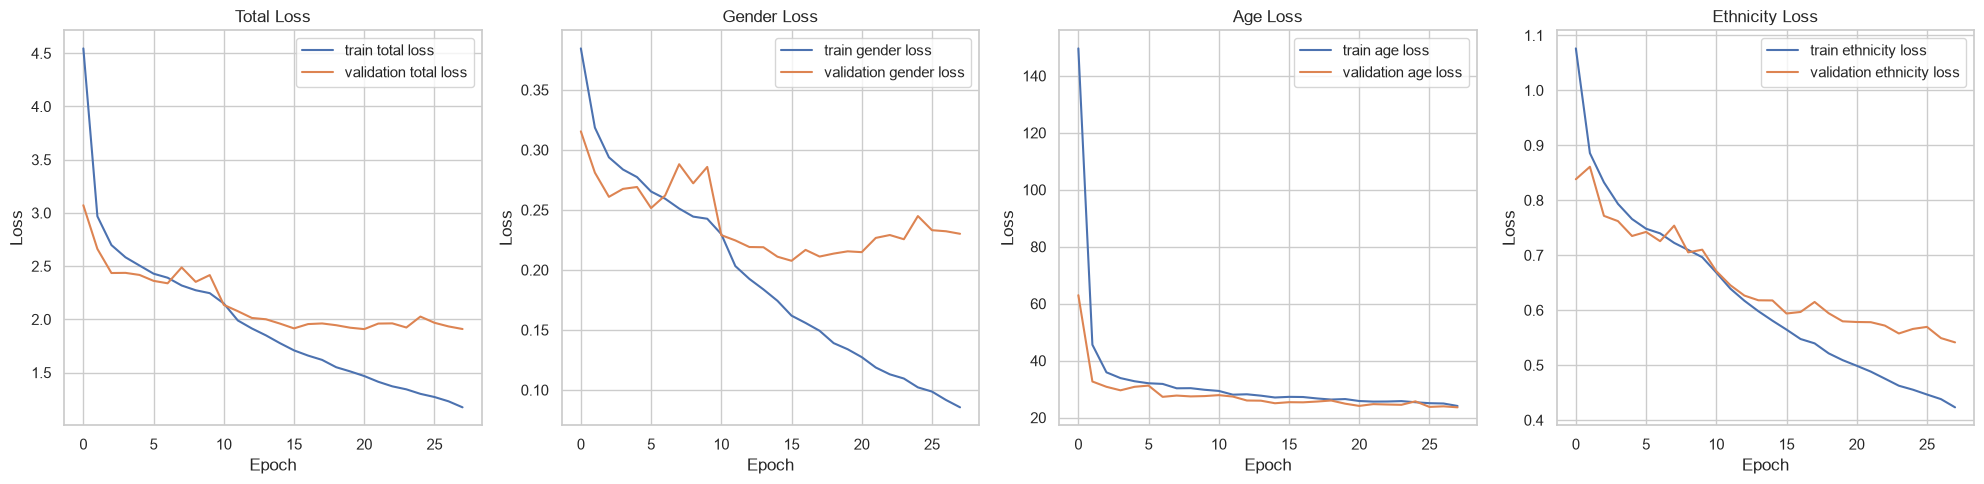

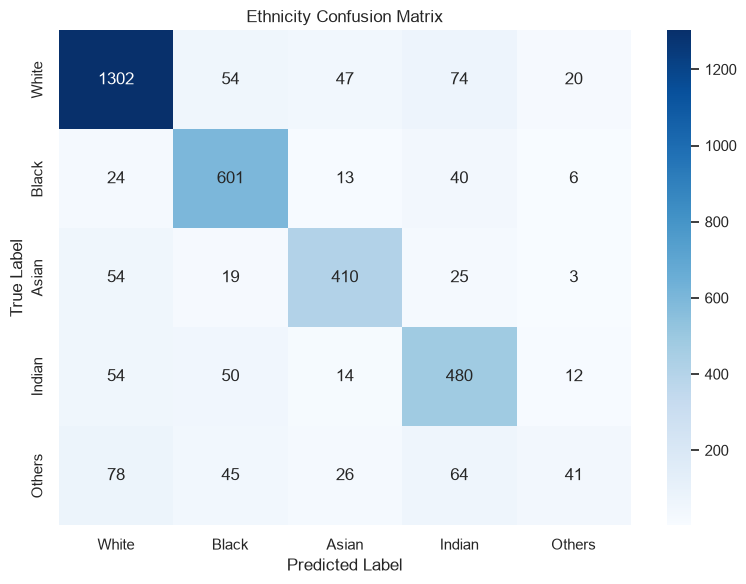

In [19]:
plt.figure(figsize=(20, 5))

# Plotting total loss
plt.subplot(1, 4, 1)
plt.plot(history.get("loss", []), label="train total loss")
plt.plot(history.get("val_loss", []), label="validation total loss")
plt.title("Total Loss")
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.legend()

# Plotting age loss
plt.subplot(1, 4, 3)
plt.plot(history.get("age_loss", []), label="train age loss")
plt.plot(history.get("val_age_loss", []), label="validation age loss")
plt.title("Age Loss")
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.legend()

# Plotting gender loss
plt.subplot(1, 4, 2)
plt.plot(history.get("gender_loss", []), label="train gender loss")
plt.plot(history.get("val_gender_loss", []), label="validation gender loss")
plt.title("Gender Loss")
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.legend()

# Plotting ethnicity loss
plt.subplot(1, 4, 4)
plt.plot(history.get("ethnicity_loss", []), label="train ethnicity loss")
plt.plot(history.get("val_ethnicity_loss", []), label="validation ethnicity loss")
plt.title("Ethnicity Loss")
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.legend()
plt.tight_layout()

# Print metrics
#for key in metrics:
#    if key != "confusion_matrix":
#        print(f"Key: {key} : value: {metrics[key]}")

print(f"Mean absolute age error: {metrics['age_mae']}")
print(f"Gender accuracy: {metrics['gender_accuracy']}")
print(f"Ethnicity accuracy: {metrics['ethnicity_accuracy']}")

# Print confusion matrix

cm = metrics['confusion_matrix']
plt.figure(figsize=(8, 6))
labels = ['White', 'Black', 'Asian', 'Indian', 'Others']
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', xticklabels=labels, yticklabels=labels)
plt.title("Ethnicity Confusion Matrix")
plt.xlabel("Predicted Label")
plt.ylabel("True Label")
plt.tight_layout()
plt.show()

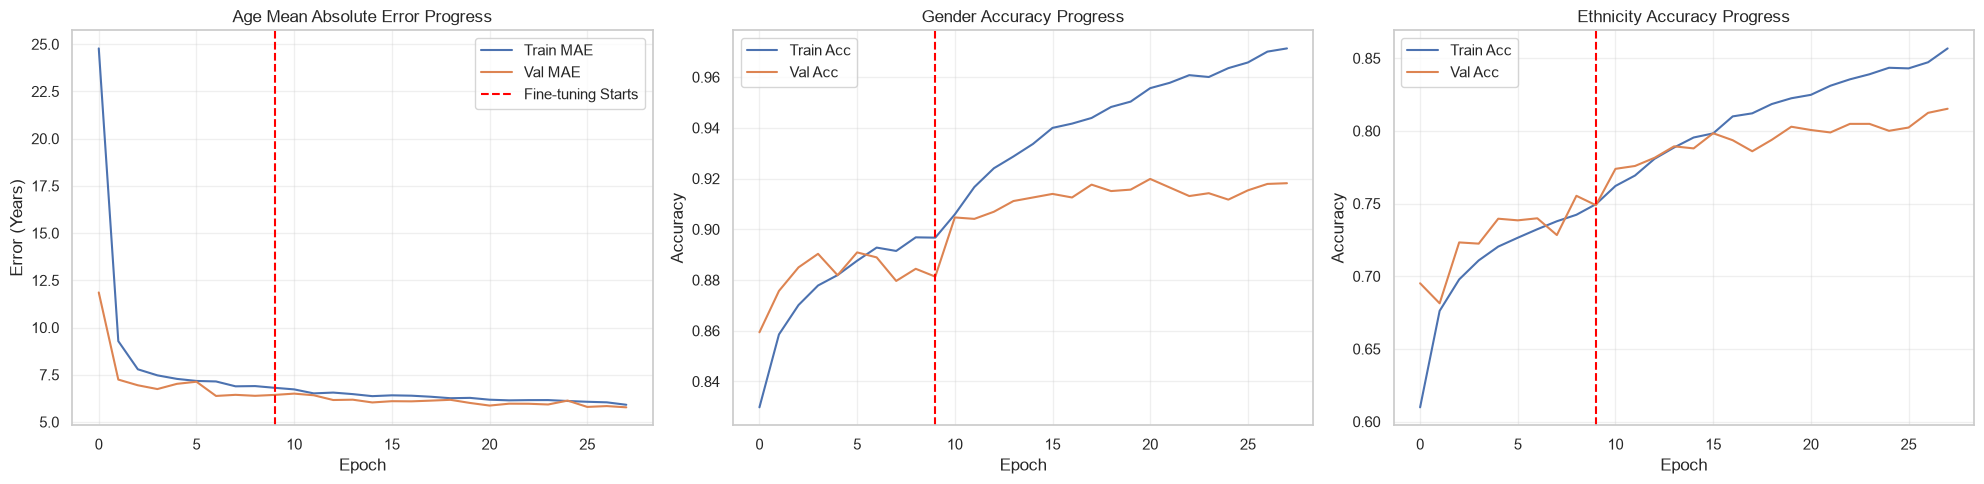

In [48]:
plt.figure(figsize=(20, 5))
phase1_end = history.get("phase1_epochs_completed", [10])[0] # Default to 10 if not explicitly a list

# 1. Age MAE Tracking
plt.subplot(1, 3, 1)
plt.plot(history.get("age_mae", []), label="Train MAE")
plt.plot(history.get("val_age_mae", []), label="Val MAE")
plt.axvline(x=phase1_end - 1, color='red', linestyle='--', label='Fine-tuning Starts')
plt.title("Age Mean Absolute Error Progress")
plt.xlabel("Epoch")
plt.ylabel("Error (Years)")
plt.legend()
plt.grid(True, alpha=0.3)

# 2. Gender Accuracy Tracking
plt.subplot(1, 3, 2)
plt.plot(history.get("gender_accuracy", []), label="Train Acc")
plt.plot(history.get("val_gender_accuracy", []), label="Val Acc")
plt.axvline(x=phase1_end - 1, color='red', linestyle='--')
plt.title("Gender Accuracy Progress")
plt.xlabel("Epoch")
plt.ylabel("Accuracy")
plt.legend()
plt.grid(True, alpha=0.3)

# 3. Ethnicity Accuracy Tracking
plt.subplot(1, 3, 3)
plt.plot(history.get("ethnicity_accuracy", []), label="Train Acc")
plt.plot(history.get("val_ethnicity_accuracy", []), label="Val Acc")
plt.axvline(x=phase1_end - 1, color='red', linestyle='--')
plt.title("Ethnicity Accuracy Progress")
plt.xlabel("Epoch")
plt.ylabel("Accuracy")
plt.legend()
plt.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

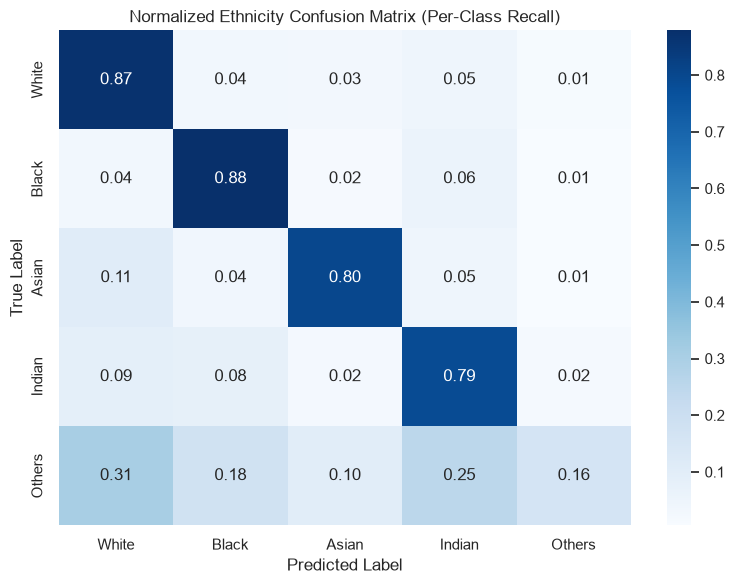

In [ ]:
cm = np.array(metrics['confusion_matrix'])
# Normalize by dividing each row by its sum (True Positive Rates)
cm_normalized = cm.astype('float') / cm.sum(axis=1)[:, np.newaxis]

plt.figure(figsize=(8, 6))
labels = ['White', 'Black', 'Asian', 'Indian', 'Others']
sns.heatmap(cm_normalized, annot=True, fmt='.2f', cmap='Blues', xticklabels=labels, yticklabels=labels)
plt.title("Normalized Ethnicity Confusion Matrix (Per-Class Recall)")
plt.xlabel("Predicted Label")
plt.ylabel("True Label")
plt.tight_layout()
plt.show()

In [4]:

import cv2


def predict_face_attributes(image_path, model_version):
    """
    Loads a specific model version and predicts Age, Gender, and Race
    matching the exact configuration of the source training pipeline.
    
    Args:
        image_path (str): Path to the input image file.
        model_version (int): Version of the model to use (1, 2, 3, or 4).
    """
    # 1. Target configurations from your training setup
    IMG_SIZE = (200, 200)
    race_labels = ['White', 'Black', 'Asian', 'Indian', 'Others']
    
    # 2. Path verification
    model_path = f'models/gpu_v{model_version}.keras'
    if not os.path.exists(model_path):
        raise FileNotFoundError(f"Model file not found at: {model_path}")
    if not os.path.exists(image_path):
        raise FileNotFoundError(f"Input image file not found at: {image_path}")
        
    # 3. Load the model
    print(f"Loading Model v{model_version} from {model_path}...")
    model = tf.keras.models.load_model(model_path)
    
    # 4. Exact Image Preprocessing Pipeline (Matching line 95-101 of your code)
    img = cv2.imread(image_path)
    img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)
    img = cv2.resize(img, IMG_SIZE)
    img = tf.cast(img, tf.float32)
    
    # CRITICAL: Using the exact ResNet50 preprocessing function from your script
    img = tf.keras.applications.resnet50.preprocess_input(img)
    input_tensor = np.expand_dims(img, axis=0)
    
    # 5. Run Inference
    print("Running inference...")
    predictions = model.predict(input_tensor, verbose=0)
    
    # 6. Parse Multi-Task Outputs using your exact dictionary keys
    # Verified directly from: outputs={"gender": ..., "age": ..., "ethnicity": ...}
    pred_age = predictions['age'].flatten()[0]
    pred_race_probs = predictions['ethnicity'].flatten()
    pred_gender_prob = predictions['gender'].flatten()[0]
    
    # 7. Post-process outputs to human-readable format
    predicted_race = race_labels[np.argmax(pred_race_probs)]
    race_confidence = np.max(pred_race_probs)
    
    if pred_gender_prob >= 0.5:
        predicted_gender = "Female"
        gender_confidence = pred_gender_prob
    else:
        predicted_gender = "Male"
        gender_confidence = 1.0 - pred_gender_prob
        
    # 8. Print Clean Summary
    print("\n" + "="*40)
    print(f"   PREDICTION RESULTS (Model v{model_version})")
    print("="*40)
    print(f"Predicted Age:    {pred_age:.1f} years old")
    print(f"Predicted Gender: {predicted_gender} ({gender_confidence:.2%})")
    print(f"Predicted Race:   {predicted_race} ({race_confidence:.2%})")
    print("="*40)
    
    return {
        "age": pred_age,
        "gender": predicted_gender,
        "race": predicted_race
    }

# --- EXECUTION BLOCK ---
# You can change model_version seamlessly between 1, 2, 3, or 4
results = predict_face_attributes(
    image_path="data/David.jpg",
    model_version=4
)

Loading Model v4 from models/gpu_v4.keras...
Running inference...

   PREDICTION RESULTS (Model v4)
Predicted Age:    67.4 years old
Predicted Gender: Male (98.93%)
Predicted Race:   White (94.20%)
